In [1]:
import pandas as pd

caminho = 'tabelas/itau_criativos_bq-results-20250919-221320-1758320027333.csv'

itau = pd.read_csv(caminho)

itau.columns

Index(['tabelaOrigem', 'origem_fluxo', 'date', 'month', 'year',
       'master_account_id', 'master_account_name', 'account_id', 'account',
       'campaign_id', 'campaign', 'ad_group_id', 'ad_group', 'ad_id',
       'ad_name', 'ad_code', 'imagem', 'instagram_link', 'facebook_link',
       'canal', 'agencia', 'media', 'brand', 'objective', 'freeform1',
       'channel', 'segmentation', 'buy', 'device', 'segmentation_type',
       'freeform2', 'formato', 'criativo', 'cost', 'impressions', 'clicks',
       'video_views', 'video_views_25', 'video_views_50', 'video_views_75',
       'video_views_100', 'likes', 'comment', 'share', 'saves', 'leads',
       'messaging_started', 'gasessions', 'ganewusers', 'gapageviews'],
      dtype='object')

In [2]:
itau_1 = itau.copy()

print(itau_1['objective'].unique())
print(itau_1['segmentation_type'].unique())
print(itau_1['freeform2'].unique())
print(itau_1['brand'].unique())
#print(itau_1['canal'].unique()) ###pode tirar
#print(itau_1['agencia'].unique()) ###pode tirar
#print(itau_1['media'].unique()) ###pode tirar
print(itau_1['freeform1'].unique())
print(itau_1['channel'].unique())
print(itau_1['segmentation'].unique())
print(itau_1['buy'].unique())
print(itau_1['formato'].unique())
itau_1 = itau_1[itau_1['formato'] == 'post']
itau_1 = itau_1[itau_1['objective'] == 'conversao']

['conversao' 'app_engagement' 'cadastro' 'mensagens' 'alcance'
 'visualizacao' 'trafego' 'brand_awareness' 'app_consideracao'
 'engajamento' 'mensagens_consideracao' 'cadastro_consideracao'
 'reconhecimento_marca' 'consideracao' 'reconhecimento_pj_consi_pj_aon']
['facebook_asc_generico' 'audience' 'facebook_asc_ouroprata'
 'fb_asc_purchase' 'crm' 'mar_aberto' 'audience_look_a_like' 'interest'
 'remarketing' 'meta_mab_asc_web_app_new' 'audience_interest'
 'meta_mab_asc_on' 'fb_asc_purchase Conjunto de anúncios'
 'facebook_asc_roas' 'meta_mab_asc_off_tg'
 'mab_asc_ts_regiao_ia_off Conjunto de anúncios' 'asc_one_web_app'
 'meta_mab_asc_one_web_app Conjunto de anúncios' 'audience_remarketing'
 'meta_mab_asc_web_app_new  Conjunto de anúncios' 'custom_affinity'
 'audience_todos_app_cl']
[nan 'base_qualificados_manual' 'base_qualificados_medalhacartoes'
 'troas_ouroprata' 'maxconv_generico' 'base_qualificados_basenova'
 'base_qualificados' 'limite_maximo' 'ouroprata_altarenda'
 'facebook_crm_

In [3]:
print(itau_1['brand'].unique())
print(itau_1['channel'].unique())
print(itau_1['buy'].unique())

['aquisicao_pf' 'personnalite' 'uniclass']
['gl' 'facebook' 'meta' '[n]facebook']
['aquisicao_pf' 'cpc' 'cpa' 'cpm' 'personnalite']


In [4]:
itau_1 = itau_1[['brand', 'channel', 'buy', 'campaign_id', 'ad_id' \
                 , 'imagem', 'ad_name', 'cost', 'impressions', 'clicks']]

itau_1 = itau_1[itau_1['cost'] >= 100]

itau_1.shape

(12124, 10)

In [5]:
check = itau_1.groupby(['ad_id', 'ad_name'])['imagem'].nunique().nlargest(10)
print(check)

check2 = itau_1[itau_1['ad_id'] == 120216457001010141]

print(check2['imagem'].unique())

ad_id              ad_name                        
23857033256870168  post-limite_maximo-gp8657746691    1
23857559612100168  post-limite_maximo-gp8831163975    1
23857560219630168  post-limite_maximo-gp4873139026    1
23857560285360168  post-limite_maximo-gp3727964243    1
23857563454700168  post-limite_maximo-gp9915451076    1
23857564146400168  post-limite_maximo-gp5545854857    1
23857564232700168  post-limite_maximo-gp7192011185    1
23857762309490168  post-limite_maximo-gp1246771347    1
23857762654400168  post-limite_maximo-gp3906647810    1
23857810441420168  post-limite_maximo-gp6697346911    1
Name: imagem, dtype: int64
[]


In [6]:
itau_agrupado = itau_1.copy()

itau_agrupado = itau_agrupado.groupby(['campaign_id', 'imagem', 'brand', 'channel', 'buy']).agg(
    {
        'cost':'sum',
        'impressions': 'sum',
        'clicks': 'sum'
    }
).reset_index()

itau_agrupado['clicksper1000impression'] = 1000*itau_agrupado['clicks']/itau_agrupado['impressions']
itau_agrupado['cpc'] = itau_agrupado['cost']/itau_agrupado['clicks']
itau_agrupado['cpm'] = 1000*itau_agrupado['cost']/itau_agrupado['impressions']
itau_agrupado['imagem'] = itau_agrupado['imagem'].str.split('/').str[-1]

itau_agrupado.head(20)
#itau_agrupado.shape

,campaign_id,imagem,brand,channel,buy,cost,impressions,clicks,clicksper1000impression,cpc,cpm
0,23852163372100168,5531544864979657732.png,aquisicao_pf,facebook,cpc,1.304111e+06,112305262.0,261224.0,2.326017,4.992309,11.612198
1,23852163372100168,6119720837473432976.png,aquisicao_pf,facebook,cpc,3.540824e+03,133803.0,753.0,5.627677,4.702289,26.462964
2,23854621553260621,4570911979816457278.png,personnalite,facebook,cpc,1.372944e+03,87863.0,306.0,3.482695,4.486744,15.625958
3,23854622078410621,4570911979816457278.png,personnalite,facebook,cpc,1.703002e+05,14328072.0,40057.0,2.795701,4.251447,11.885774
4,23855767830780621,4570911979816457278.png,personnalite,facebook,cpc,2.110011e+04,2125560.0,6756.0,3.178457,3.123165,9.926846
5,23857032799540168,5531544864979657732.png,aquisicao_pf,facebook,cpc,1.374775e+04,1934988.0,8419.0,4.350931,1.632943,7.104825
6,23857271791290168,5531544864979657732.png,aquisicao_pf,facebook,cpc,6.368277e+05,51047726.0,104190.0,2.041031,6.112177,12.475143
7,23857271791290168,6119720837473432976.png,aquisicao_pf,facebook,cpc,3.260702e+04,2897519.0,8065.0,2.783416,4.043028,11.253429
8,23857294214960168,5531544864979657732.png,aquisicao_pf,facebook,cpc,7.025762e+05,71116446.0,178997.0,2.516956,3.925073,9.879237
9,23857294214960168,6119720837473432976.png,aquisicao_pf,facebook,cpc,6.014519e+03,434389.0,1327.0,3.054866,4.532418,13.845929


In [7]:
verificado = itau_agrupado.copy()

print(len(verificado['campaign_id'].unique()))

verificado = verificado[['campaign_id', 'brand', 'channel', 'buy']].drop_duplicates()

print(verificado.shape)

print(verificado.groupby('campaign_id')['campaign_id'].count().nlargest(5))

print(itau_agrupado[itau_agrupado['campaign_id'] == 120211110534840622])

107
(110, 4)
campaign_id
120209823008790622    2
120211110534840622    2
120212308807790169    2
23852163372100168     1
23854621553260621     1
Name: campaign_id, dtype: int64
           campaign_id                   imagem         brand   channel  buy  \
92  120211110534840622  4449748108322139938.png  personnalite  facebook  cpm   
93  120211110534840622  6364351563189207463.png  personnalite  facebook  cpc   
94  120211110534840622  6364351563189207463.png  personnalite  facebook  cpm   
95  120211110534840622  7492290952585167622.png  personnalite  facebook  cpc   
96  120211110534840622  7492290952585167622.png  personnalite  facebook  cpm   
97  120211110534840622   923631624733589915.png  personnalite  facebook  cpm   

             cost  impressions    clicks  clicksper1000impression        cpc  \
92   30663.111004     959713.0    4891.0                 5.096315   6.269293   
93    1144.965833      59100.0     142.0                 2.402707   8.063140   
94    8381.600001     

In [8]:
# 1. Carrega o arquivo usando a orientação de índice
# Isso transforma as chaves principais (nomes dos arquivos) em linhas
df_imagem = pd.read_json('resultados_ia.json', orient='index')

# 2. (Opcional) O nome do arquivo estará no índice (index) do DataFrame.
# Se você quiser transformar o nome do arquivo em uma coluna normal:
df_imagem = df_imagem.reset_index().rename(columns={'index': 'arquivo'})
df_imagem = df_imagem[['arquivo', 'brainai_index', 'focus_index', 'cognitive_demand_index']]

# Exibe o resultado
print(df_imagem.head())

                   arquivo  brainai_index  focus_index  cognitive_demand_index
0  8572474697454358902.jpg      85.466591     7.835850               85.647281
1  4187168035276168277.jpg      73.444573     8.626669               67.825190
2  6119720837473432976.png      65.899812     8.845279               51.455920
3  4300327416286945370.jpg      39.847908    64.721964               32.503734
4  2782306428767059128.png      86.968133     9.553435               74.676456


In [9]:
df_final = pd.merge(
    itau_agrupado,
    df_imagem,
    left_on='imagem',    # Coluna do df_esquerda
    right_on='arquivo',    # Coluna do df_direita
    how='inner'
)

df_final = df_final.drop(columns='arquivo')

print(df_final.sort_values(by = 'clicksper1000impression').head())

            campaign_id                   imagem         brand   channel  buy  \
18    23857810221950168  6119720837473432976.png  aquisicao_pf  facebook  cpc   
17    23857810221950168  5531544864979657732.png  aquisicao_pf  facebook  cpc   
22    23861734727700168  6119720837473432976.png  aquisicao_pf  facebook  cpc   
185  120215123123760169   896585436487528564.png  aquisicao_pf  facebook  cpm   
183  120215123123760169  7991215369354574151.png  aquisicao_pf  facebook  cpm   

             cost  impressions  clicks  clicksper1000impression       cpc  \
18    6738.560017    2681695.0  1933.0                 0.720813  3.486063   
17    9108.651815    3402191.0  2801.0                 0.823293  3.251929   
22   18721.241095    4814574.0  4379.0                 0.909530  4.275232   
185    115.930000      58711.0    61.0                 1.038988  1.900492   
183   1049.603770     430705.0   501.0                 1.163209  2.095018   

          cpm  brainai_index  focus_index  cogniti

In [10]:
# 1. Calcula a matriz de correlação completa entre todas as variáveis
# Por padrão, usa o método Pearson.
matriz_correlacao = df_final[['cost', 'brainai_index', 'focus_index', 'cognitive_demand_index', 'clicksper1000impression']].corr()

# 2. Isola a coluna da variável resposta ('clicksperimpression')
# Esta Series agora contém a correlação de cada feature com a variável resposta.
correlacao_com_resposta = matriz_correlacao['clicksper1000impression']

# 3. (Opcional) Ordena os valores para ver o ranking das features
# Usamos .drop() para remover a autocorrelação (1.0)
correlacao_ordenada = correlacao_com_resposta.drop('clicksper1000impression').sort_values(ascending=False)

print("--- Correlação das Features com clicksperimpression ---")
print(correlacao_ordenada)

--- Correlação das Features com clicksperimpression ---
cognitive_demand_index    0.023509
focus_index              -0.034315
brainai_index            -0.042643
cost                     -0.117396
Name: clicksper1000impression, dtype: float64


In [11]:
import pandas as pd

# 1. Filtro inicial: Remover campanhas com apenas 1 imagem
# Contamos quantas imagens tem por campanha
contagem = df_final.groupby('campaign_id')['imagem'].transform('count')
df_filtered = df_final[contagem > 1].copy()

# 2. O Self-Join (O segredo da combinação 2 a 2)
# Cruzamos o dataframe com ele mesmo usando o campaign_id como chave
df_comb = pd.merge(df_filtered, df_filtered, on='campaign_id', suffixes=('1', '2'))

# 3. Filtro para não repetir combinações e não comparar a imagem com ela mesma
# A lógica: Pegamos apenas onde o nome da imagem 1 é "menor" (alfabeticamente) que a imagem 2.
# Isso garante que teremos (A vs B), mas remove (B vs A) e (A vs A).
df_comb = df_comb[df_comb['imagem1'] < df_comb['imagem2']]

# 4. Cálculo das Variações (Diferença entre Imagem 1 e Imagem 2)
# Se o resultado for positivo, a imagem 1 tinha um índice maior.
df_comb['delta_brainai'] = df_comb['brainai_index1'] - df_comb['brainai_index2']
df_comb['delta_cognitive'] = df_comb['cognitive_demand_index1'] - df_comb['cognitive_demand_index2']
df_comb['delta_focus'] = df_comb['focus_index1'] - df_comb['focus_index2']

# 5. Definição do Vencedor (Lógica Binária)
# 1 se a Imagem 1 tiver mais clicks/1000, 0 caso contrário (ou seja, a Imagem 2 ganhou)
df_comb['vencedor'] = (df_comb['cost1'] > df_comb['cost2']).astype(int)

# 6. Seleção e Renomeação final das colunas
colunas_finais = [
    'campaign_id',
    'imagem1', 'imagem2',
    'brand1', 'brand2',
    'channel1', 'channel2',
    'buy1', 'buy2',
    'delta_brainai',         # Variação BrainAI
    'delta_cognitive',       # Variação Cognitive Demand
    'delta_focus',           # Variação Focus
    'vencedor'               # Target (1 = Imagem1 ganhou, 0 = Imagem2 ganhou)
]

df_final = df_comb[colunas_finais]
df_final = df_final[df_final['brand1'] == df_final['brand2']]
df_final = df_final[df_final['channel1'] == df_final['channel2']]
df_final = df_final[df_final['buy1'] == df_final['buy2']]

# Exibir resultado
print(f"Total de pares gerados: {len(df_final)}")
df_final.head()

Total de pares gerados: 166


,campaign_id,imagem1,imagem2,brand1,brand2,channel1,channel2,buy1,buy2,delta_brainai,delta_cognitive,delta_focus,vencedor
1,23852163372100168,5531544864979657732.png,6119720837473432976.png,aquisicao_pf,aquisicao_pf,facebook,facebook,cpc,cpc,1.147808,8.660651,-0.016946,1
5,23857271791290168,5531544864979657732.png,6119720837473432976.png,aquisicao_pf,aquisicao_pf,facebook,facebook,cpc,cpc,1.147808,8.660651,-0.016946,1
9,23857294214960168,5531544864979657732.png,6119720837473432976.png,aquisicao_pf,aquisicao_pf,facebook,facebook,cpc,cpc,1.147808,8.660651,-0.016946,1
13,23857538220570168,5531544864979657732.png,6119720837473432976.png,aquisicao_pf,aquisicao_pf,facebook,facebook,cpc,cpc,1.147808,8.660651,-0.016946,0
17,23857540117480168,5531544864979657732.png,6119720837473432976.png,aquisicao_pf,aquisicao_pf,gl,gl,aquisicao_pf,aquisicao_pf,1.147808,8.660651,-0.016946,1


In [12]:
from sklearn.model_selection import train_test_split

X = df_final[['delta_brainai', 'delta_cognitive', 'delta_focus']]#, 'cost', 'brainai_index', 'focus_index', 'cognitive_demand_index']]
# X = pd.get_dummies(
#     X, 
#     columns=['brand', 'channel', 'buy'],  # 1. Escolhe SÓ as colunas que você quer converter
#     drop_first=True,      # 3. Remove a primeira coluna para evitar redundância*
#     dtype=int             # 4. Força sair 0 e 1
# )

print(X.columns)

y = df_final['vencedor']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, 
    test_size=0.2, 
    random_state=42 # Para garantir que a divisão seja a mesma sempre
)

print(X.head(5))
print('-'*60)
print(y.head(5))

Index(['delta_brainai', 'delta_cognitive', 'delta_focus'], dtype='object')
    delta_brainai  delta_cognitive  delta_focus
1        1.147808         8.660651    -0.016946
5        1.147808         8.660651    -0.016946
9        1.147808         8.660651    -0.016946
13       1.147808         8.660651    -0.016946
17       1.147808         8.660651    -0.016946
------------------------------------------------------------
1     1
5     1
9     1
13    0
17    1
Name: vencedor, dtype: int64


In [13]:
# import matplotlib.pyplot as plt
# import seaborn as sns

# # Plota a distribuição do Y de treino e Y de teste
# plt.figure(figsize=(10, 4))
# sns.histplot(y_train, color='blue', label='Treino', kde=True)
# sns.histplot(y_test, color='orange', label='Teste', kde=True)
# plt.legend()
# plt.title("Distribuição da Variável Alvo (Clicks/1k)")
# plt.show()

# # Ver estatísticas descritivas
# print("Max Treino:", y_train.max())
# print("Max Teste:", y_test.max())

In [14]:
# 1. Calcula a matriz de correlação completa entre todas as variáveis
# Por padrão, usa o método Pearson.
matriz_correlacao = df_final[['delta_brainai', 'delta_cognitive', 'delta_focus', 'vencedor']].corr()

# 2. Isola a coluna da variável resposta ('clicksperimpression')
# Esta Series agora contém a correlação de cada feature com a variável resposta.
correlacao_com_resposta = matriz_correlacao['vencedor']

# 3. (Opcional) Ordena os valores para ver o ranking das features
# Usamos .drop() para remover a autocorrelação (1.0)
correlacao_ordenada = correlacao_com_resposta.drop('vencedor').sort_values(ascending=False)

print("--- Correlação das Features com vencedor ---")
print(correlacao_ordenada)

--- Correlação das Features com vencedor ---
delta_focus        0.119111
delta_cognitive    0.092859
delta_brainai     -0.120895
Name: vencedor, dtype: float64


In [15]:
from sklearn.tree import DecisionTreeClassifier

# 1. Cria o modelo (Decision Tree Regressor)
# Definimos uma profundidade máxima (max_depth) de 5. 
# Profundidades pequenas garantem interpretabilidade.
arvore = DecisionTreeClassifier(
    max_depth=4, 
    random_state=42
)

# 2. Treina o modelo
print("Iniciando o treinamento do Decision Tree Regressor...")
arvore.fit(X_train, y_train)
print("Treinamento concluído.")

# 3. Faz previsões no conjunto de teste
y_pred = arvore.predict(X_test)

Iniciando o treinamento do Decision Tree Regressor...
Treinamento concluído.


Acurácia Geral: 64.71%
------------------------------
              precision    recall  f1-score   support

           0       0.65      0.79      0.71        19
           1       0.64      0.47      0.54        15

    accuracy                           0.65        34
   macro avg       0.64      0.63      0.63        34
weighted avg       0.65      0.65      0.64        34



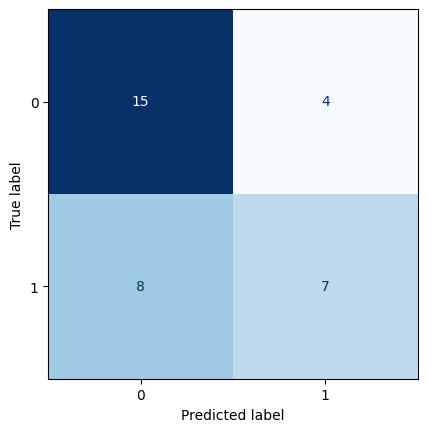

In [16]:
from sklearn.metrics import accuracy_score, classification_report, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

# 1. Faça as previsões no seu conjunto de TESTE (dados que o modelo nunca viu)
y_pred = arvore.predict(X_test)

# 2. Calcule a Acurácia Geral
# (Percentual de acertos)
acc = accuracy_score(y_test, y_pred)
print(f"Acurácia Geral: {acc:.2%}")
print("-" * 30)

# 3. Veja o Relatório de Classificação (O MAIS IMPORTANTE)
# Mostra a performance para CADA classe
print(classification_report(y_test, y_pred))

ConfusionMatrixDisplay.from_predictions(
    y_test, 
    y_pred, 
    cmap='Blues',
    colorbar=False
)

plt.show()

In [17]:
import pandas as pd
import matplotlib.pyplot as plt

# 1. Extrai a importância das features
importances = arvore.feature_importances_

# 2. Cria um DataFrame para facilitar a visualização
# X_train.columns contém os nomes das features
feature_importances_df = pd.DataFrame({
    'Feature': X_train.columns,
    'Importance': importances
})

# 3. Ordena pela importância decrescente
feature_importances_df = feature_importances_df.sort_values(by='Importance', ascending=False)

# Exibe o resultado
print(feature_importances_df)

           Feature  Importance
2      delta_focus    0.647233
0    delta_brainai    0.341958
1  delta_cognitive    0.010809


In [18]:
import xgboost as xgb

# 1. Cria o modelo (XGBoost Regressor)
bostao = xgb.XGBClassifier(
    objective='binary:logistic', # Objetivo para regressão com erro quadrático
    n_estimators=200,             # Aumentamos o número de árvores para melhor performance
    learning_rate=0.05,           # Taxa de aprendizado
    max_depth=5,                  # Profundidade máxima de cada árvore
    random_state=42,
    n_jobs=-1                     # Usa todos os cores da CPU
)

# 2. Treina o modelo
print("Iniciando o treinamento do XGBoost Regressor...")
bostao.fit(X_train, y_train)
print("Treinamento concluído.")

Iniciando o treinamento do XGBoost Regressor...
Treinamento concluído.


Acurácia Geral: 67.65%
------------------------------
              precision    recall  f1-score   support

           0       0.70      0.74      0.72        19
           1       0.64      0.60      0.62        15

    accuracy                           0.68        34
   macro avg       0.67      0.67      0.67        34
weighted avg       0.67      0.68      0.68        34



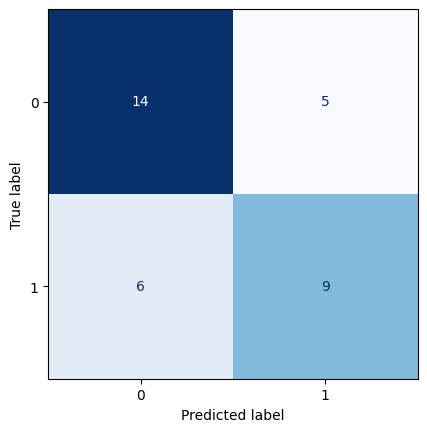

In [19]:
from sklearn.metrics import accuracy_score, classification_report, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

# 1. Faça as previsões no seu conjunto de TESTE (dados que o modelo nunca viu)
y_pred = bostao.predict(X_test)

# 2. Calcule a Acurácia Geral
# (Percentual de acertos)
acc = accuracy_score(y_test, y_pred)
print(f"Acurácia Geral: {acc:.2%}")
print("-" * 30)

# 3. Veja o Relatório de Classificação (O MAIS IMPORTANTE)
# Mostra a performance para CADA classe
print(classification_report(y_test, y_pred))

ConfusionMatrixDisplay.from_predictions(
    y_test, 
    y_pred, 
    cmap='Blues',
    colorbar=False
)

plt.show()

In [20]:
import pandas as pd
import matplotlib.pyplot as plt

# 1. Extrai a importância das features
importances = bostao.feature_importances_

# 2. Cria um DataFrame para facilitar a visualização
# X_train.columns contém os nomes das features
feature_importances_df = pd.DataFrame({
    'Feature': X_train.columns,
    'Importance': importances
})

# 3. Ordena pela importância decrescente
feature_importances_df = feature_importances_df.sort_values(by='Importance', ascending=False)

# Exibe o resultado
print(feature_importances_df)

           Feature  Importance
2      delta_focus    0.562878
0    delta_brainai    0.273070
1  delta_cognitive    0.164053


In [21]:
# from sklearn.tree import DecisionTreeRegressor
# from sklearn.metrics import r2_score, mean_squared_error

# # 1. Cria o modelo (Decision Tree Regressor)
# # Definimos uma profundidade máxima (max_depth) de 5. 
# # Profundidades pequenas garantem interpretabilidade.
# dt_reg = DecisionTreeRegressor(
#     max_depth=4, 
#     random_state=42
# )

# # 2. Treina o modelo
# print("Iniciando o treinamento do Decision Tree Regressor...")
# dt_reg.fit(X_train, y_train)
# print("Treinamento concluído.")

# # 3. Faz previsões no conjunto de teste
# y_pred_dt_reg = dt_reg.predict(X_test)

# # 4. Avalia a performance

# # R² (Coeficiente de Determinação: Mede a variação explicada pelo modelo. 1.0 é perfeito.)
# r2_dt = r2_score(y_test, y_pred_dt_reg)
# print(f"\nCoeficiente R² da Árvore de Regressão: {r2_dt:.4f}")

# # MSE (Erro Quadrático Médio: Penaliza erros maiores. Quanto menor, melhor.)
# mse_dt = mean_squared_error(y_test, y_pred_dt_reg)
# print(f"Erro Quadrático Médio (MSE): {mse_dt:.6f}")

In [22]:
# import pandas as pd
# import matplotlib.pyplot as plt

# # 1. Extrai a importância das features
# importances = dt_reg.feature_importances_

# # 2. Cria um DataFrame para facilitar a visualização
# # X_train.columns contém os nomes das features
# feature_importances_df = pd.DataFrame({
#     'Feature': X_train.columns,
#     'Importance': importances
# })

# # 3. Ordena pela importância decrescente
# feature_importances_df = feature_importances_df.sort_values(by='Importance', ascending=False)

# # Exibe o resultado
# print(feature_importances_df)

In [23]:
# import xgboost as xgb

# # 1. Cria o modelo (XGBoost Regressor)
# model_reg = xgb.XGBRegressor(
#     objective='reg:squarederror', # Objetivo para regressão com erro quadrático
#     n_estimators=200,             # Aumentamos o número de árvores para melhor performance
#     learning_rate=0.05,           # Taxa de aprendizado
#     max_depth=5,                  # Profundidade máxima de cada árvore
#     random_state=42,
#     n_jobs=-1                     # Usa todos os cores da CPU
# )

# # 2. Treina o modelo
# print("Iniciando o treinamento do XGBoost Regressor...")
# model_reg.fit(X_train, y_train)
# print("Treinamento concluído.")

In [24]:
# # 1. Faz previsões no conjunto de teste
# y_pred_reg = model_reg.predict(X_test)

# # 2. Avalia a performance

# # R² (Explica a variância: 1.0 é perfeito)
# r2 = r2_score(y_test, y_pred_reg)
# print(f"\nCoeficiente R² do Modelo: {r2:.4f}")

# # MSE (Erro Quadrático Médio: quanto menor, melhor)
# mse = mean_squared_error(y_test, y_pred_reg)
# print(f"Erro Quadrático Médio (MSE): {mse:.6f}")

In [25]:
# # 1. Extrai a importância das features
# importances = model_reg.feature_importances_

# # 2. Cria um DataFrame para facilitar a visualização
# # X_train.columns contém os nomes das features
# feature_importances_df = pd.DataFrame({
#     'Feature': X_train.columns,
#     'Importance': importances
# })

# # 3. Ordena pela importância decrescente
# feature_importances_df = feature_importances_df.sort_values(by='Importance', ascending=False)

# # Exibe o resultado
# print(feature_importances_df)